# WISE on BPIC'19 — basic method evaluation
### *Weighted Insights for Evaluating Efficiency* · norm-based scoring · slice-first prioritisation

This notebook is a **basic, paper-faithful implementation and evaluation** of the WISE method
(Jessen, Fahland, Zerbato — *"WISE: Actionable Norm-Based Scoring for Process Mining"*)
on the **BPI Challenge 2019** purchase-to-pay benchmark, answering the challenge's **Question 3**:

> *Which Purchase Documents stand out from the log? Where are deviations from the discovered
> processes and how severe are they? Deviations may be according to the prescribed high-level
> process flow, but also with respect to the values of the invoices. Which customers produce
> a lot of rework as invoices are wrong, etc.?*

WISE bridges the gap between **case-level event-log diagnostics** and the **ownership-aligned
decisions** improvement initiatives actually need. It turns *expectations and log evidence into
comparable priorities*:

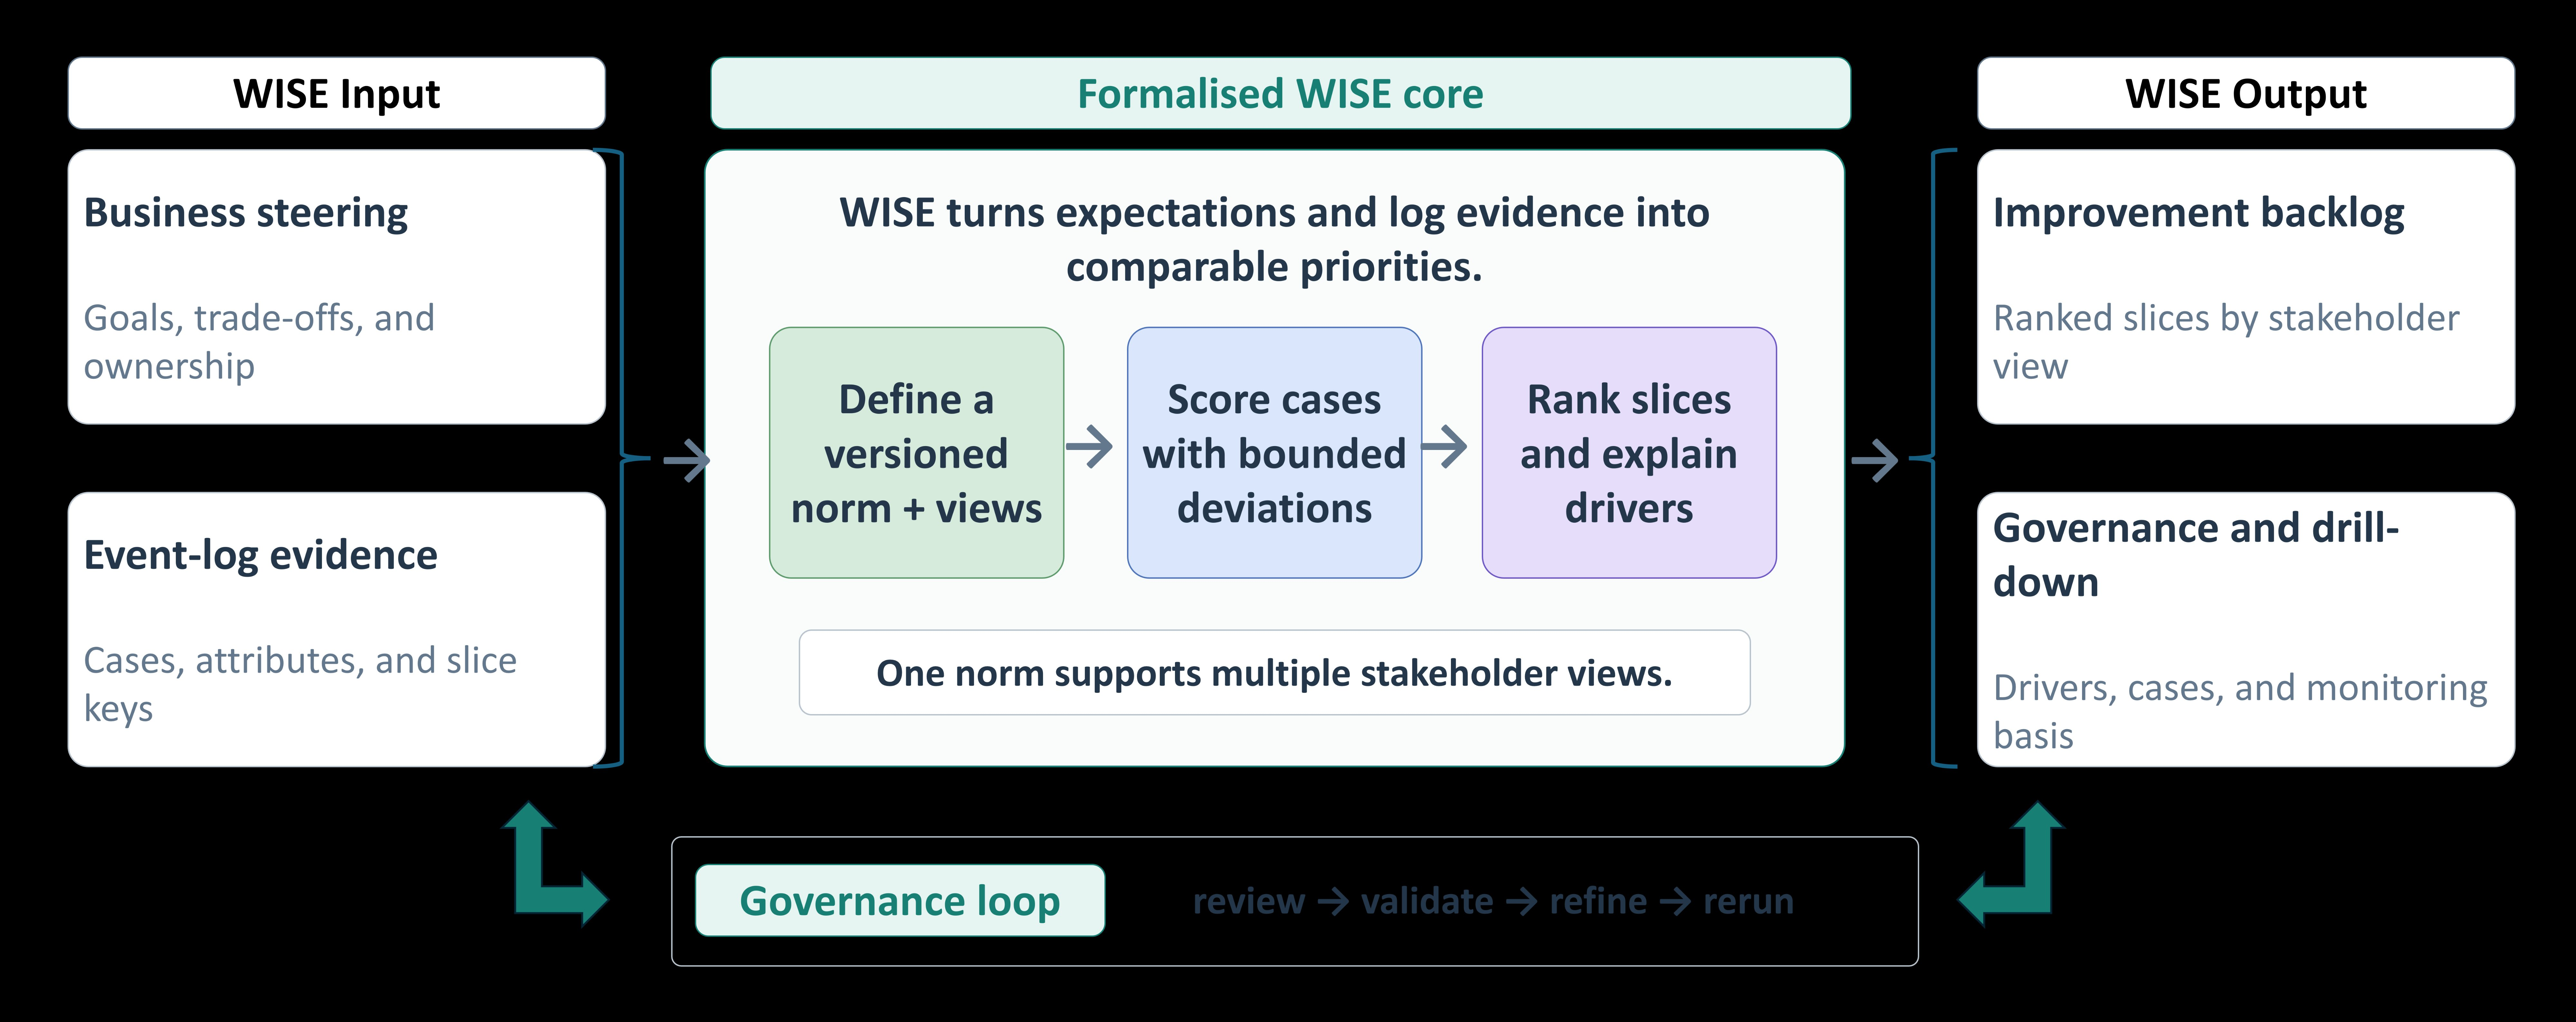

**Three core ideas** (left → right in the figure above):

1. **Define a versioned norm + views** — a compact, stakeholder-owned, machine-checkable
   specification of expected execution. *One norm supports multiple stakeholder views.*
2. **Score cases with bounded deviations** — every constraint maps a case to a violation
   signal $\nu_c(\sigma)\in[0,1]$, so heterogeneous evidence (counts, lags, mismatches)
   becomes comparable and aggregation stays stable.
3. **Rank slices and explain drivers** — case evidence is aggregated to *slices*
   (cohorts of cases defined by business attributes that map to accountable owners) and
   ranked by a **Priority Index = scale × underperformance**, with drill-down to layers,
   constraints, and cases.


## The workflow this notebook follows — paper Figure 2

The notebook is organised **exactly** along the detailed WISE workflow (Fig. 2 of the paper).
Every section header below names the band of this figure it implements:

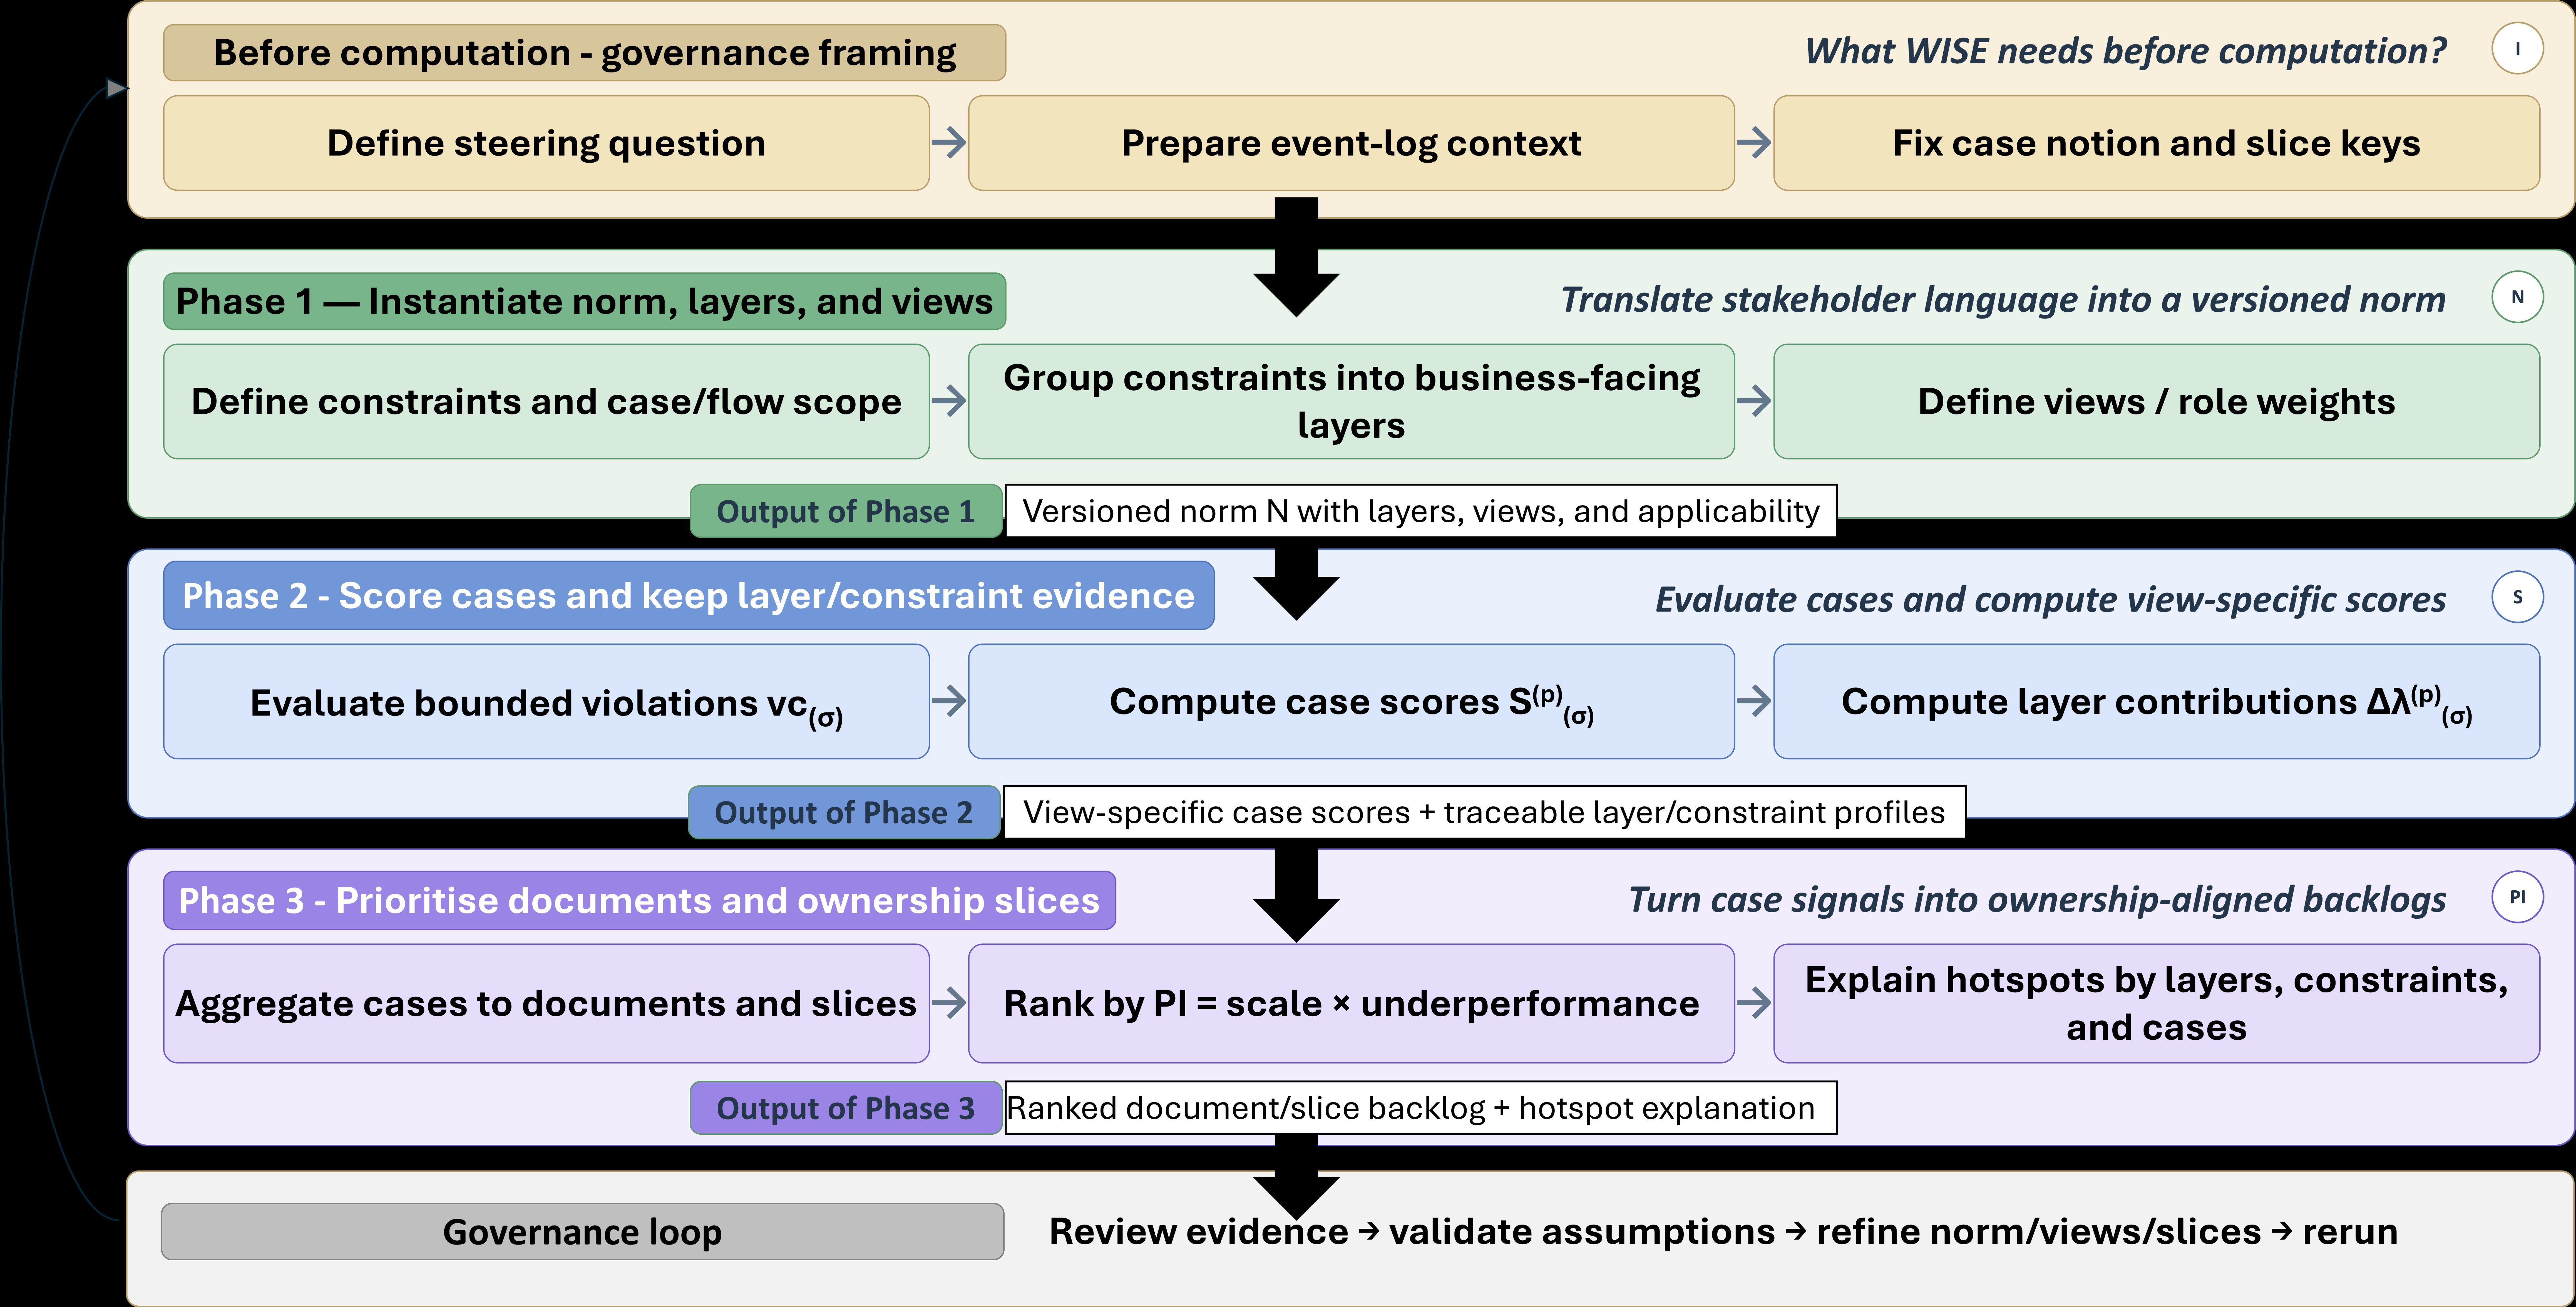

| Notebook section | Figure 2 band | Output |
|---|---|---|
| **0. Governance framing** | *Before computation* | steering question, event-log context, case notion + slice keys |
| **1. Phase 1** | *Instantiate norm, layers, and views* | versioned norm $N$ with layers, views, and applicability |
| **2. Phase 2** | *Score cases and keep layer/constraint evidence* | view-specific case scores + traceable layer/constraint profiles |
| **3. Phase 3** | *Prioritise documents and ownership slices* | ranked document/slice backlog + hotspot explanation |
| **4. Governance loop** | *Review evidence → validate assumptions → refine → rerun* | data-quality qualification of every finding (paper **Table X**, here with real numbers) |

All method mathematics lives in the supporting **`wise_eval/` package** (one module per Fig. 2 band);
the notebook orchestrates, prints, explains, and visualises. The norm itself is a **versioned JSON
artefact** (`norm/bpic19_norm_v1.json`) — explicit, auditable, reusable, per the paper's governance
requirement.


In [1]:
# =============================================================================
# Imports and configuration
# -----------------------------------------------------------------------------
# THEORY | Governance & auditability gap (paper Sec. II-E, gap 3): decision-layer
# artefacts -- norms, weights, aggregation choices -- must be explicit,
# versionable, and auditable. We therefore keep every methodological choice in
# wise.config.CONFIG (one block, no hidden magic numbers downstream) and load
# the norm from a *versioned JSON file* rather than constructing it ad hoc.
# =============================================================================
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))      # make the local `wise` package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Make wise_eval/ importable regardless of where Jupyter / VS Code was started.
# VS Code always sets __vsc_ipynb_file__ to the notebook absolute path — its
# parent is the project root. We try that first, then cwd() upward/downward.
# ---------------------------------------------------------------------------
import sys, os
from pathlib import Path

def _project_root():
    # 1. VS Code: __vsc_ipynb_file__ is injected into every cell's globals
    nb_path = globals().get("__vsc_ipynb_file__")
    if nb_path:
        p = Path(nb_path).resolve().parent
        if (p / "wise_eval" / "__init__.py").exists():
            return p
        if (p.parent / "wise_eval" / "__init__.py").exists():
            return p.parent
    # 2. Walk upward from cwd
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "wise_eval" / "__init__.py").exists():
            return p
    # 3. One level down from cwd
    for sub in sorted(Path.cwd().iterdir()):
        if sub.is_dir() and (sub / "wise_eval" / "__init__.py").exists():
            return sub
    raise FileNotFoundError(
        "Cannot find wise_eval/. "
        "Place wise_eval/, norm/ and figures/ in the same folder as "
        "WISE_BPIC19_basic_evaluation.ipynb and open that folder in VS Code."
    )

PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"project root: {PROJECT_ROOT}")

from wise_eval.config import CONFIG, RNG_SEED
from wise_eval import data, features, norm as wnorm, constraints as wcons
from wise_eval import scoring, prioritization as prio, governance as gov, viz

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
np.random.seed(RNG_SEED)

print("WISE basic evaluation | seed =", RNG_SEED)
print("Slicing function g(σ):", " × ".join(CONFIG["slice_keys"]))
print("Shrinkage γ =", CONFIG["shrinkage_gamma"],
      "| censoring window =", CONFIG["censoring_window_days"], "days",
      "| replication flag >", CONFIG["replication_ratio_flag"])

project root: /Users/ula/code/PhD/WISE/WISE/Untitled
WISE basic evaluation | seed = 42
Slicing function g(σ): case Company × case Spend area text
Shrinkage γ = 20.0 | censoring window = 60 days | replication flag > 2.0


---
## 0 · Before computation — governance framing
*(Figure 2, top band: define steering question → prepare event-log context → fix case notion and slice keys)*

**Steering question.** A WISE analysis starts from a *business* question, not a mining task.
For BPIC'19 we use the challenge's **Q3**, operationalised (paper Sec. V-A) as:

* **Q3.1 — Stand-out documents:** which purchasing documents (PO headers) stand out relative to the baseline, and which should be addressed first?
* **Q3.2 — Deviations:** where does recorded behaviour deviate from expected behaviour *under the appropriate flow type*, and which process problems do these deviations indicate?
* **Q3.3 — Value deviations and rework producers:** where do value-related issues and rework concentrate (vendors, spend areas, item types, …)?

**Event-log context.** The real BPIC'19 log contains **1,595,923 events for 251,734 PO line
items in 76,349 purchasing documents** from an SAP-like P2P process. The challenge distinguishes
**four flow types** with *different* completeness and control expectations — flow typing is a
prerequisite for any normative assessment, because the same event pattern may be compliant in one
flow type and deviant in another:

| Flow | Meaning | Key expectation difference |
|---|---|---|
| **DF1** | 3-way match, invoice **after** GR/SES | goods/service evidence must precede invoice |
| **DF2** | 3-way match, invoice **may precede** GR/SES | payment block + release is part of the intended control |
| **2-way** | no GR/SES expected | receipt expectations must NOT be imposed |
| **Consignment** | invoicing typically outside log scope | IR/CI often not expected |

**Case notion and slice keys.** The **case σ = PO item** (Purchasing Document × Item) — matching,
blocking, corrections, partial deliveries all happen at item level in SAP. The **purchasing
document (PO header)** is the *governance roll-up* for the stand-out question. The **primary
slicing function** is $g(\sigma) = $ *company × spend area* — keys that map to accountable owners —
with vendor, item type, and case-start quarter as drill-down keys.

> **Data note.** If the real CSV is absent the notebook generates a synthetic BPIC'19-like log with
> three **planted** hotspots matching the paper's typology (reservoir / mechanism / severity).
> The pipeline thereby validates itself: it must *rediscover* the planted patterns, *type* them
> correctly, and *qualify* them in the governance loop.

In [2]:
# =============================================================================
# 0.1 | Prepare event-log context: load, clean, flow-type, fix the case notion
# -----------------------------------------------------------------------------
# wise.data implements the "Before computation" band of Fig. 2: it loads the
# real BPIC'19 CSV when present (CONFIG["csv_candidates"]) and otherwise
# synthesises a schema-identical fallback with planted hotspots; it then maps
# `case Item Category` to the four flow types and derives case_id (PO item),
# purchasing_document (governance unit), and case_start_quarter (temporal key
# used later by the governance loop).
# =============================================================================
df_raw, DATA_SOURCE, csv_path = data.load_raw_log()
print(f"Data source: {DATA_SOURCE}" + (f" ({csv_path})" if csv_path else " (synthetic fallback with planted hotspots)"))

df = data.prepare_log(df_raw)
print(f"Prepared event log: {df.shape[0]:,} events | {df['case_id'].nunique():,} PO items "
      f"| {df['purchasing_document'].nunique():,} purchasing documents")
print("\nFlow-type case distribution (the applicability backbone of the norm):")
display(df.drop_duplicates("case_id")["flow_type"].value_counts().rename_axis("flow_type").to_frame("cases"))

[data] loading REAL BPIC'19 log: /Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv
[data] read 1,595,923 rows x 22 columns
Data source: BPIC19 (/Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv)
Prepared event log: 1,595,923 events | 251,734 PO items | 76,349 purchasing documents

Flow-type case distribution (the applicability backbone of the norm):


,cases
flow_type,
DF2,221010
DF1,15182
Consignment,14498
2-way,1044


In [3]:
# =============================================================================
# 0.2 | Case-level feature extraction (one row per PO item)
# -----------------------------------------------------------------------------
# THEORY (paper Sec. IV-A) | Constraints read only *named, documented columns*:
#   cnt(a, σ)   -> count__<activity>        activity occurrence counts
#   t1(a, σ)    -> first_ts__<activity>     first-occurrence timestamps
#   exp(σ)      -> exposure_abs_max         business exposure (net worth) for
#                                           the exposure-weighted PI variant
# plus effort features for the L7 layer (manual_share, total_events, distinct
# human resources), a net-worth volatility proxy for L6 balance checks, and
# two governance-loop inputs: case_last_ts (right-censoring) and
# event_replication_ratio (events per distinct timestamp).
# Keeping signals as named columns -- not opaque embeddings -- is what keeps
# the norm auditable: every ν_c(σ) can be traced to documented evidence.
# =============================================================================
df_case = features.build_case_features(df)
print(f"Case feature frame: {df_case.shape[0]:,} cases × {df_case.shape[1]} columns")
display(df_case[["case_id", "flow_type", "case Company", "case Spend area text",
                 "total_events", "manual_share", "exposure_abs_max",
                 "event_replication_ratio"]].head(5))

Case feature frame: 251,734 cases × 115 columns


,case_id,flow_type,case Company,case Spend area text,total_events,manual_share,exposure_abs_max,event_replication_ratio
0,2000000000_00001,DF2,companyID_0000,CAPEX & SOCS,12,0.333333,298.0,2.000000
1,2000000001_00001,DF1,companyID_0000,Marketing,15,0.400000,557.0,2.142857
2,2000000002_00001,DF1,companyID_0000,Marketing,18,0.388889,76210.0,2.000000
3,2000000003_00001,DF2,companyID_0000,Enterprise Services,12,0.333333,28.0,2.000000
4,2000000003_00002,DF2,companyID_0000,Enterprise Services,12,0.333333,37.0,2.000000


---
## 1 · Phase 1 — Instantiate norm, layers, and views
*(Figure 2, green band: define constraints and case/flow scope → group constraints into business-facing layers → define views / role weights.
**Output:** versioned norm $N$ with layers, views, and applicability.)*

### 1.1 Theory — what a process norm is

A **process norm** is a triple (paper Sec. IV-C)

$$N = (C, \Lambda, \mathrm{lay})$$

* $C$ — a finite set of **machine-checkable constraints**, each mapping a case to a *bounded* violation $\nu_c(\sigma)\in[0,1]$;
* $\Lambda$ — a finite set of **business-facing layers** (named deviation mechanisms);
* $\mathrm{lay}: C \to \Lambda$ — assigns each constraint to **exactly one** layer, so $\{C_\lambda\}$ **partitions** $C$.

WISE deliberately restricts the constraint vocabulary to **five recurring types** that match how
stakeholders phrase expectations (paper Table II) — expressive enough for recurring steering
concerns, small enough to stay stakeholder-owned and maintainable:

| Type | Encodes | Violation semantics |
|---|---|---|
| **pres** | required activities occur | $\nu = 1-\min(\mathrm{cnt}(a,\sigma)/m,\,1)$ — indicator-like for $m{=}1$ |
| **lag / order** | intended ordering + timeliness window | $\nu = \mathrm{sat}(\ell;\,\delta,\Delta)$ on the lag $\ell = t_1(b)-t_1(a)$ |
| **sing** | bounded repetitions (rework proxy) | $\nu = \min\!\big(\max(0,\mathrm{cnt}-k)/K,\,1\big)$ |
| **excl** | rare/forbidden exceptions | $\nu = \mathbb{1}[\mathrm{cnt}(a,\sigma)>0]$ — any occurrence is maximal |
| **bal** | numeric consistency within tolerance | $\nu = \mathrm{sat}(d_c(\sigma);\,\tau,\Gamma)$ on the relative mismatch |

All **graded** types share one generic **threshold–saturation rule**:

$$\mathrm{sat}(z;\vartheta,W)=\begin{cases}0, & z\le\vartheta\\[2pt] \min\!\big(\tfrac{z-\vartheta}{W},\,1\big), & z>\vartheta\end{cases}$$

— deviations up to the tolerated threshold $\vartheta$ cost nothing, larger deviations are penalised
linearly, and the signal **caps at 1** once $z \ge \vartheta + W$. Example: $\vartheta{=}10,\ W{=}20$
⇒ sat(8)=0, sat(15)=0.25, sat(20)=0.5, sat(30)=1. Bounding is what makes counts, lags, and
mismatches *commensurable* and keeps every later aggregate stable against outliers.

### 1.2 Theory — why layers, and why views

**Layers** provide the *intermediate explanation level* between individual violations and an overall
score: rather than reporting dozens of isolated rule hits, a slice is later explained by stating
**which deviation mechanisms dominate its profile** — while drill-down to constraints and cases is
preserved. Layer names are *not* additional constraints; they are an explanatory grouping that also
aligns the output with ownership.

A **view** $p$ is a non-negative raw weight vector $\langle w_c^{(p)}\rangle_{c\in C}$ over the
**shared** constraint set. Crucially: *views do not define different norms — they define different
priorities over the same norm.* That is what lets the same case evidence answer Finance, Logistics,
Compliance, and Automation questions **without redefining a single check**.

**Two-stage weight elicitation** (optional but used here, paper Sec. IV-C): first each view assigns
**layer weights** $a_\lambda^{(p)} \ge 0$ with $\sum_\lambda a_\lambda^{(p)} = 1$, then each
constraint receives a **within-layer weight** $b_c$ (shared across views in the BPIC'19
instantiation), normalised as $\hat b_c = b_c / \sum_{d \in C_\lambda} b_d$. The raw weight is the
product

$$w_c^{(p)} = a_{\mathrm{lay}(c)}^{(p)} \cdot \hat b_c .$$

The scoring equations use **only** the resulting $w_c^{(p)}$ — they do not depend on how the weights
were obtained. The two-stage form simply makes the view design inspectable: *first* state which
business-facing layers matter for a role, *then* distribute that weight inside each layer.

In [4]:
# =============================================================================
# 1.3 | Load the versioned norm artefact and inspect N = (C, Λ, lay)
# -----------------------------------------------------------------------------
# The BPIC'19 norm was constructed manually as a transparent benchmark
# instantiation (the public challenge gives no access to process owners),
# combining the challenge description, the four flow types, P2P domain
# knowledge, and declarative/compliance-oriented logic. It contains
# 29 constraints across 7 layers, each with explicit thresholds, saturation
# widths, and *flow-aware applicability* -- e.g. no receipt expectations on
# 2-way items, no invoice-clearing expectations on consignment items
# (this is what prevents false positives, paper Table VII).
# =============================================================================
norm = wnorm.load_norm()
print(f"Norm: {norm['metadata']['name']}  (version {norm['metadata']['version']})")
print(f"Case notion: {norm['metadata']['case_notion']} | governance unit: {norm['metadata']['governance_unit']}")
print(f"|C| = {len(norm['constraints'])} constraints, |Λ| = {len(norm['layers'])} layers, "
      f"{len(norm['views'])} views\n")

print("THE SEVEN BUSINESS-FACING LAYERS Λ — the explanatory vocabulary of the evaluation")
print("=" * 96)
for lid, l in norm["layers"].items():
    print(f"\n  {lid}  ·  {l['name']}")
    print(f"      business question : {l['question']}")
    print(f"      rationale         : {l['explanation']}")

Norm: WISE BPIC'19 Full-Log Norm  (version 1.0-paper-aligned)
Case notion: PO item (Purchasing Document × Item) | governance unit: Purchase document (PO header)
|C| = 29 constraints, |Λ| = 7 layers, 4 views

THE SEVEN BUSINESS-FACING LAYERS Λ — the explanatory vocabulary of the evaluation

  L1_closure_completeness  ·  Expected completion and closure
      business question : Which cases remain incomplete or unresolved relative to the expected flow?
      rationale         : Captures missing commercial or settlement milestones. This layer is the main bridge from raw event data to stand-out backlogs.

  L2_flow_discipline  ·  Flow-conditioned control discipline
      business question : Does the observed control path fit the intended process type?
      rationale         : Separates DF1, DF2, 2-way match, and consignment. This is the layer for process-type-specific normative expectations.

  L3_timeliness_ageing  ·  Handovers and ageing
      business question : Where are the main hando

In [5]:
# =============================================================================
# 1.4 | The full constraint catalogue C, grouped by layer (paper Table VII logic)
# -----------------------------------------------------------------------------
# Read each row as: WHICH layer it explains, HOW it is checked (paper-type
# vocabulary pres/lag/order/sing/excl/bal), WHERE it applies (flow-aware
# C_app), and WHAT business mechanism it captures. The flow column is the
# applicability mapping in action: a check absent from a flow can never
# penalise a case of that flow.
# =============================================================================
rows = []
for c in norm["constraints"]:
    rows.append({
        "layer": c["layer_id"].split("_")[0],
        "constraint_id": c["id"],
        "type (paper)": c.get("paper_type", c["type"]),
        "applicable flows (C_app)": ", ".join(c["applicable_flows"]),
        "business mechanism": c["description"],
    })
catalogue = pd.DataFrame(rows)
print(f"Full norm catalogue — {len(catalogue)} constraints "
      f"({catalogue['type (paper)'].value_counts().to_dict()})")
display(catalogue)

Full norm catalogue — 29 constraints ({'sing': 10, 'excl': 7, 'lag': 4, 'pres': 3, 'order': 2, 'bal_proxy': 2, 'bal': 1})


,layer,constraint_id,type (paper),applicable flows (C_app),business mechanism
0,L1,c_l1_invoice_present,pres,"DF1, DF2, 2-way",Invoice evidence should exist for invoice-bear...
1,L1,c_l1_clear_invoice_present,pres,"DF1, DF2, 2-way",Invoice-bearing flows should eventually be cle...
2,L1,c_l1_goods_or_ses_present,pres,"DF1, DF2",3-way flows should contain goods or service re...
3,L2,c_l2_df1_invoice_after_goods,order,DF1,"In DF1, invoice evidence should not precede th..."
4,L2,c_l2_df2_release_after_goods,order,DF2,"In DF2, payment-block release should happen af..."
5,L2,c_l2_2way_no_goods_expected,excl,2-way,2-way match should not show goods/service rece...
6,L2,c_l2_consignment_no_clear_invoice,excl,Consignment,Consignment should normally not be settled thr...
7,L3,c_l3_df1_goods_to_invoice_days,lag,DF1,"In DF1, invoice should follow goods/service wi..."
8,L3,c_l3_invoice_to_clear_days,lag,"DF1, DF2, 2-way",Invoice-bearing flows should clear in a reason...
9,L3,c_l3_df2_goods_to_rpb_days,lag,DF2,"In DF2, goods/service to Remove Payment Block ..."


In [6]:
# =============================================================================
# 1.5 | ALL WEIGHTS, PRINTED AND EXPLAINED
# -----------------------------------------------------------------------------
# Three artefacts fully determine every score in this notebook:
#   (a) layer weights a_λ^(p)        -- per view, columns sum to 1 (Table VIII)
#   (b) within-layer weights b̂_c    -- shared across views
#   (c) raw constraint weights w_c^(p) = a_λ^(p) · b̂_c  -- what scoring consumes
# Printing them in full is not decoration: it is the WISE governance
# requirement that prioritisation logic be explicit and discussable.
# =============================================================================
# ---- (a) layer weights — paper Table VIII -----------------------------------
layer_tab = wnorm.layer_weight_table(norm)
print("(a) LAYER-LEVEL ROLE WEIGHTS a_λ^(p)  — paper Table VIII (focal layers per view in CAPS)")
show = layer_tab.copy()
for v in norm["views"]:
    col = show[v]
    mx = col.max()
    show[v] = [f"{x:.2f}" + ("  ◀" if x == mx else "") for x in col]
print(show.to_string())
print("\ncolumn sums:", {v: round(float(layer_tab[v].sum()), 2) for v in norm["views"]})

print("\nWHY THESE WEIGHTS — the rationale of each view (stakeholder priorities, not estimates):")
for v, info in norm["views"].items():
    focal = layer_tab[v].astype(float).idxmax()
    print(f"\n  {v:<11} focal layer: {focal} ({norm['layers'][focal]['name']})")
    print(f"  {'':<11} {info['why']}")
print("\nNOTE (paper Table VIII): these are illustrative evaluation settings, not empirically "
      "estimated\ncoefficients or stakeholder-elicited priorities — in a real engagement they "
      "are negotiated\nwith the roles and versioned alongside the norm.")

(a) LAYER-LEVEL ROLE WEIGHTS a_λ^(p)  — paper Table VIII (focal layers per view in CAPS)
                                                    layer_name  Finance Logistics Compliance Automation
layer_id                                                                                               
L1_closure_completeness        Expected completion and closure  0.24  ◀      0.08       0.12       0.06
L2_flow_discipline         Flow-conditioned control discipline     0.08   0.24  ◀    0.30  ◀       0.08
L3_timeliness_ageing                      Handovers and ageing  0.24  ◀      0.22       0.10       0.10
L4_rework_instability                   Rework and instability     0.06      0.22       0.06       0.28
L5_exceptions_corrections           Exceptions and corrections     0.08      0.08       0.26       0.06
L6_value_commercial             Value and commercial integrity  0.24  ◀      0.04       0.06       0.08
L7_effort_automation            Effort and automation friction     0.06      0.

In [7]:
# ---- (b) within-layer weights b̂_c (shared across views) ---------------------
# The within-layer weight states how much a constraint matters *relative to its
# layer siblings*. Sharing b̂ across views keeps the view design 7-dimensional
# (layer level) instead of 29-dimensional — easier to negotiate and to audit.
wl = wnorm.within_layer_weights(norm)
print("(b) WITHIN-LAYER WEIGHTS b̂_c — shared across all views; each layer block sums to 1")
display(wl[["layer_id", "constraint_id", "paper_type", "b_c (raw)", "b̂_c (normalised)"]]
        .style.format({"b̂_c (normalised)": "{:.3f}"}) if False else
        wl[["layer_id", "constraint_id", "paper_type", "b_c (raw)", "b̂_c (normalised)"]].round(3))
chk = wl.groupby("layer_id")["b̂_c (normalised)"].sum().round(6)
print("per-layer sums (must all be 1.0):", chk.to_dict())

(b) WITHIN-LAYER WEIGHTS b̂_c — shared across all views; each layer block sums to 1


,layer_id,constraint_id,paper_type,b_c (raw),b̂_c (normalised)
0,L1_closure_completeness,c_l1_invoice_present,pres,1.2,0.324
1,L1_closure_completeness,c_l1_clear_invoice_present,pres,1.4,0.378
2,L1_closure_completeness,c_l1_goods_or_ses_present,pres,1.1,0.297
3,L2_flow_discipline,c_l2_df1_invoice_after_goods,order,1.4,0.286
4,L2_flow_discipline,c_l2_df2_release_after_goods,order,1.5,0.306
5,L2_flow_discipline,c_l2_2way_no_goods_expected,excl,1.2,0.245
6,L2_flow_discipline,c_l2_consignment_no_clear_invoice,excl,0.8,0.163
7,L3_timeliness_ageing,c_l3_df1_goods_to_invoice_days,lag,1.3,0.250
8,L3_timeliness_ageing,c_l3_invoice_to_clear_days,lag,1.5,0.288
9,L3_timeliness_ageing,c_l3_df2_goods_to_rpb_days,lag,1.2,0.231


per-layer sums (must all be 1.0): {'L1_closure_completeness': 1.0, 'L2_flow_discipline': 1.0, 'L3_timeliness_ageing': 1.0, 'L4_rework_instability': 1.0, 'L5_exceptions_corrections': 1.0, 'L6_value_commercial': 1.0, 'L7_effort_automation': 1.0}


(c) RAW CONSTRAINT WEIGHTS w_c^(p) per view  — the product a_λ^(p) · b̂_c


,layer_id,paper_type,b̂_c (normalised),w^(Finance),w^(Logistics),w^(Compliance),w^(Automation)
constraint_id,,,,,,,
c_l1_invoice_present,L1_closure_completeness,pres,0.3243,0.0778,0.0259,0.0389,0.0195
c_l1_clear_invoice_present,L1_closure_completeness,pres,0.3784,0.0908,0.0303,0.0454,0.0227
c_l1_goods_or_ses_present,L1_closure_completeness,pres,0.2973,0.0714,0.0238,0.0357,0.0178
c_l2_df1_invoice_after_goods,L2_flow_discipline,order,0.2857,0.0229,0.0686,0.0857,0.0229
c_l2_df2_release_after_goods,L2_flow_discipline,order,0.3061,0.0245,0.0735,0.0918,0.0245
c_l2_2way_no_goods_expected,L2_flow_discipline,excl,0.2449,0.0196,0.0588,0.0735,0.0196
c_l2_consignment_no_clear_invoice,L2_flow_discipline,excl,0.1633,0.0131,0.0392,0.0490,0.0131
c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,lag,0.2500,0.0600,0.0550,0.0250,0.0250
c_l3_invoice_to_clear_days,L3_timeliness_ageing,lag,0.2885,0.0692,0.0635,0.0288,0.0288


per-view sums (1.0 by construction): {'w^(Finance)': 1.0, 'w^(Logistics)': 1.0, 'w^(Compliance)': 1.0, 'w^(Automation)': 1.0}


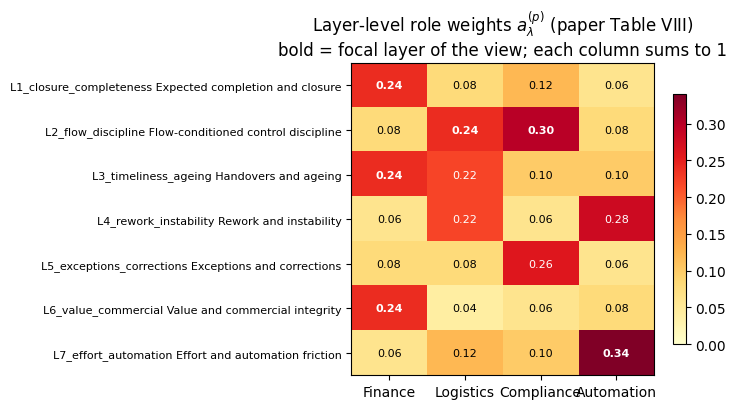

In [8]:
# ---- (c) final raw constraint weights w_c^(p) = a_λ^(p) · b̂_c ---------------
# These 29 × 4 numbers are the ONLY weight quantities the scoring equations
# consume. Reading example: a constraint with b̂_c = 0.30 inside a layer that
# Finance weights at 0.24 carries w^(Finance) = 0.072 of the Finance penalty
# budget (before per-case applicability renormalisation).
w_raw = wnorm.raw_constraint_weights(norm)
print("(c) RAW CONSTRAINT WEIGHTS w_c^(p) per view  — the product a_λ^(p) · b̂_c")
display(w_raw.round(4))
print("per-view sums (1.0 by construction):",
      {f"w^({v})": round(float(w_raw[f'w^({v})'].sum()), 3) for v in norm["views"]})

# Visual: the layer-weight heatmap (Table VIII as a figure)
fig = viz.fig_layer_weights(layer_tab)
plt.show()

**Output of Phase 1** *(Figure 2 green band)* — a **versioned norm $N$ with layers, views, and
applicability**: 29 machine-checkable constraints partitioned into 7 business-facing layers,
flow-aware applicability $C_{app}$, and 4 role-based views over the *same* catalogue. The artefact
is the JSON file `norm/bpic19_norm_v1.json`: it can be reviewed, diffed, and re-used across
analyses — translating stakeholder expectations is a first-class, versionable specification
problem, not an informal pre-step to mining.

---
## 2 · Phase 2 — Score cases and keep layer/constraint evidence
*(Figure 2, blue band: evaluate bounded violations $\nu_c(\sigma)$ → compute case scores $S^{(p)}(\sigma)$ → compute layer contributions $\Delta\lambda^{(p)}(\sigma)$.
**Output:** view-specific case scores + traceable layer/constraint profiles.)*

### Theory — from violations to scores to drivers

**(i) Violation matrix.** Evaluating every applicable constraint on every case yields two explicit
objects: the violation matrix $V \in [0,1]^{n_{\text{cases}}\times n_{\text{constraints}}}$ holding
$\nu_c(\sigma)$ (NaN where not applicable) and the applicability mask $M \in \{0,1\}^{\dots}$
realising $C_{app}$. *Everything downstream is a masked weighted average over $(V, M)$.*

**(ii) Case score.** The applicability-aware score under view $p$ is the complement of the weighted
average violation over the applicable constraints (paper Sec. IV-D):

$$S^{(p)}(\sigma) \;=\; 1-\frac{\sum_{c\in C_{app}(\sigma)} w_c^{(p)}\,\nu_c(\sigma)}{\sum_{c\in C_{app}(\sigma)} w_c^{(p)}}\;\in\;[0,1]$$

— $S^{(p)}(\sigma)=0.8$ means "the applicable constraints have a weighted average violation of 0.2
under view $p$". Cases with no positively weighted applicable constraint are unscored and excluded
from aggregation.

**(iii) Layer contributions — the drill-down currency.** A single score ranks cases but cannot
*explain* slices. Define case-specific effective weights $\tilde w^{(p)}_{c,\sigma}$ (raw weights
renormalised over the applicable set, zero outside it). Because the layers **partition** the norm,
the case penalty decomposes **exactly**:

$$1-S^{(p)}(\sigma)=\sum_{\lambda\in\Lambda}\Delta_\lambda^{(p)}(\sigma),\qquad
\Delta_\lambda^{(p)}(\sigma)=\sum_{c\in C_\lambda}\tilde w^{(p)}_{c,\sigma}\,\nu_c(\sigma).$$

Nothing is lost, nothing double-counted — that exactness is why slice explanations built from
$\Delta_\lambda$ are trustworthy. A **driver** is any interpretable penalty source (a layer or a
constraint) whose contribution explains a material part of under-performance.

*Implementation note:* the BPIC'19 instantiation evaluates layer penalties with the shared
within-layer weights $\hat b_c$ first and then takes the view-weighted average across applicable
layers ("layer-balanced" mode) — the two-stage elicitation applied at scoring time; lag constraints
are only scored when both boundary events exist, with *missing* milestones penalised once in the
closure layer L1 to avoid double counting.

In [9]:
# =============================================================================
# 2.1 | STAGE 1 of scoring — violation matrix V and applicability mask M
# -----------------------------------------------------------------------------
# wise.constraints implements the Sec. IV-B semantics: pres / lag / order /
# sing / excl / bal(+proxies), all funnelled through the threshold-saturation
# rule sat(z; ϑ, W). NaN encodes σ ∉ C_app for that constraint.
# =============================================================================
df_violations, V, M = wcons.build_violation_matrix(df_case, norm)
constraint_ids = [c["id"] for c in norm["constraints"]]
print(f"V (cases × constraints): {V.shape} | applicability density M̄ = {M.mean():.1%}")
print("  -> on average each case is checked against "
      f"{M.sum(axis=1).mean():.1f} of the {len(constraint_ids)} constraints (flow-aware C_app)")

# Raw, view-independent global mechanism signals (paper Sec. V, Q3.2 numbers):
def _cnt(col):
    s = df_case[col] if col in df_case.columns else pd.Series(0.0, index=df_case.index)
    return s.fillna(0)

inv_bearing = (_cnt("count__record_invoice_receipt")
               + _cnt("count__vendor_creates_invoice")) > 0
no_clear = _cnt("count__clear_invoice") == 0
open_rate = float((inv_bearing & no_clear).sum() / max(int(inv_bearing.sum()), 1))
ageing = df_violations["c_l3_invoice_to_clear_days"]
ageing_pos = float((ageing > 0).sum() / max(int(ageing.notna().sum()), 1))
print(f"\nRAW GLOBAL MECHANISM SIGNALS (view-independent):")
print(f"  • {open_rate:.1%} of invoice-bearing items never reach Clear Invoice "
      f"(L1 closure constraint fires)   [paper, real log: 22.6%]")
print(f"  • {ageing_pos:.1%} of applicable items show positive IR→CI ageing severity "
      f"(L3 lag > threshold)            [paper, real log: 68.7%]")

V (cases × constraints): (251734, 29) | applicability density M̄ = 76.2%
  -> on average each case is checked against 22.1 of the 29 constraints (flow-aware C_app)

RAW GLOBAL MECHANISM SIGNALS (view-independent):
  • 13.3% of invoice-bearing items never reach Clear Invoice (L1 closure constraint fires)   [paper, real log: 22.6%]
  • 88.9% of applicable items show positive IR→CI ageing severity (L3 lag > threshold)            [paper, real log: 68.7%]


GLOBAL BASELINES μ̄^(p) — the reference each slice is later compared against
  μ̄^(Finance   ) = 0.819   (mean weighted violation 18.1%, 251,734 scored cases)
  μ̄^(Logistics ) = 0.817   (mean weighted violation 18.3%, 251,734 scored cases)
  μ̄^(Compliance) = 0.871   (mean weighted violation 12.9%, 251,734 scored cases)
  μ̄^(Automation) = 0.844   (mean weighted violation 15.6%, 251,734 scored cases)
  [paper, real log: 0.82 / 0.82 / 0.87 / 0.84 — average weighted violation 13–18% per item]

Decomposition check (view Finance):  max |Σ_λ Δλ − (1−S)| = 1.67e-16  ✓ exact


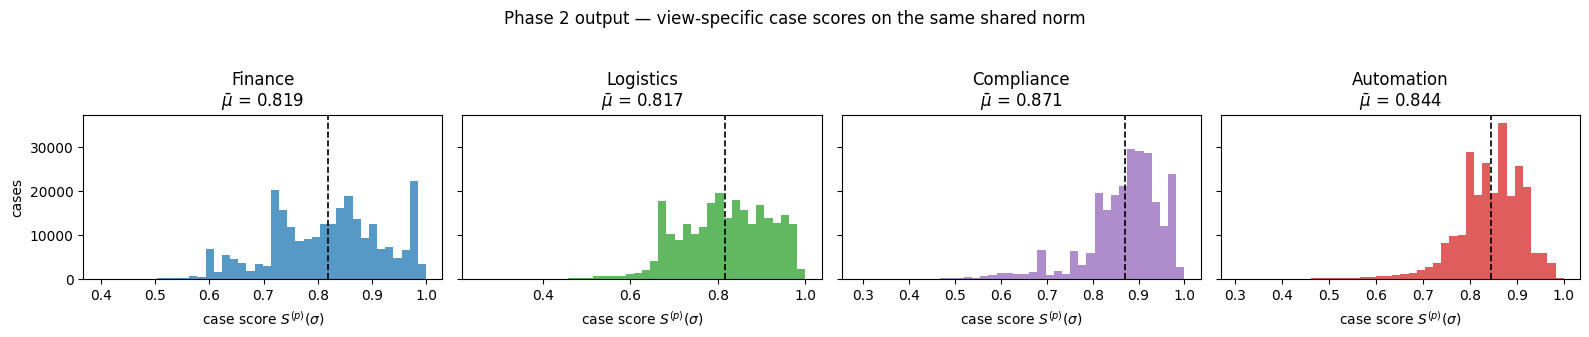

In [10]:
# =============================================================================
# 2.2 | STAGE 2 of scoring — layer penalties, case scores S^(p), contributions Δλ
# -----------------------------------------------------------------------------
# The decomposition identity  1 − S^(p)(σ) = Σ_λ Δ_λ^(p)(σ)  is verified
# numerically below — the methodological guarantee behind every slice
# explanation in Phase 3.
# =============================================================================
df_layerpen = scoring.compute_layer_penalties(df_violations, norm)
df_scores, df_contribs = scoring.compute_view_scores(df_layerpen, norm)
df_case_scores = scoring.assemble_case_scores(df_case, df_violations, df_layerpen,
                                              df_scores, df_contribs)
views = list(norm["views"].keys())

print("GLOBAL BASELINES μ̄^(p) — the reference each slice is later compared against")
for v in views:
    s = df_case_scores[f"score__{v}"]
    print(f"  μ̄^({v:<10}) = {s.mean():.3f}   (mean weighted violation {1-s.mean():.1%}, "
          f"{int(s.notna().sum()):,} scored cases)")
print("  [paper, real log: 0.82 / 0.82 / 0.87 / 0.84 — average weighted violation 13–18% per item]")

# --- verify the exact layer decomposition -----------------------------------
v0 = views[0]
recon = df_contribs[[c for c in df_contribs.columns if c.startswith(f"contrib__{v0}__")]].sum(axis=1)
err = float((recon - (1 - df_scores[f"score__{v0}"])).abs().max())
print(f"\nDecomposition check (view {v0}):  max |Σ_λ Δλ − (1−S)| = {err:.2e}  ✓ exact")

fig = viz.fig_score_distributions(df_case_scores, views)
plt.show()

**Output of Phase 2** *(Figure 2 blue band)* — **view-specific case scores + traceable
layer/constraint profiles**: one bounded score per case and view, plus the exact layer
decomposition $\Delta_\lambda^{(p)}(\sigma)$ per case. Note in the figure how the **same shared
norm** yields *different* distributions per view — the views re-weight the identical evidence; no
check was redefined. These item-level outputs are the **only** input to Phase 3; every later
explanation decomposes back to them.

---
## 3 · Phase 3 — Prioritise documents and ownership slices
*(Figure 2, purple band: aggregate cases to documents and slices → rank by PI = scale × underperformance → explain hotspots by layers, constraints, and cases.
**Output:** ranked document/slice backlog + hotspot explanation.)*

### Theory — the Priority Index

For slice $s$ with case set $\Sigma_s$, size $n_s$, slice mean $\mu_s^{(p)}$ and global mean
$\bar\mu^{(p)}$ (paper Sec. IV-E):

$$\mathrm{PI}^{(p)}_s = n_s\cdot\big(\bar\mu^{(p)}-\mu^{(p)}_s\big)_+ \qquad\text{(case-volume variant; } E_s \text{ replaces } n_s \text{ for exposure weighting)}$$

A slice rises in the backlog only when a meaningful score gap **and** sufficient scale *coincide* —
"act where deviations occur at scale". Worked example from the paper: $\bar\mu = 0.94$, slice mean
$0.80$, $n_s = 240$ ⇒ gap $0.14$, $\mathrm{PI} = 240 \cdot 0.14 = 33.6$; a much smaller slice with a
larger gap can still rank lower.

**Shrinkage stabilisation** guards against noisy small slices: with constant $\gamma \ge 0$,

$$\tilde\mu_s = \tfrac{n_s}{n_s+\gamma}\,\mu_s + \tfrac{\gamma}{n_s+\gamma}\,\bar\mu,\qquad
\widetilde{\mathrm{PI}}_s = v_s\cdot\big(\bar\mu-\tilde\mu_s\big)_+ .$$

Small $n_s$ ⇒ the mean is pulled toward the baseline (a 20-case slice with $\gamma{=}20$ keeps half
its observed gap); large $n_s$ ⇒ the stabilised mean approaches the observed one; $\gamma=0$
recovers the basic PI. We use **stable PI** ($\gamma = 20$) throughout.

### The hotspot typology — *why* a slice is prioritised matters

High-PI slices are **not all important for the same reason** (paper Sec. V, an operational WISE
typology, not established literature labels):

| Type | Signature | Implied follow-up |
|---|---|---|
| **Reservoir** | very large $n_s$, moderate gap | backlog/queue management at scale (the "vital few" of quality work) |
| **Mechanism** | mid-size, one layer/constraint dominates | targeted process redesign / automation review of that mechanism |
| **Severity** | small $n_s$, large gap | focused local review of policy, routing, or configuration |

BACKLOG CONCENTRATION — share of PO headers needed to capture priority mass
  Finance     80% of stable PI in top 2,039 docs (2.7%)   |   95% in top 7,643 docs (10.0%)   of 76,349
  Logistics   80% of stable PI in top 2,110 docs (2.8%)   |   95% in top 7,420 docs (9.7%)   of 76,349
  Compliance  80% of stable PI in top 1,771 docs (2.3%)   |   95% in top 7,012 docs (9.2%)   of 76,349
  Automation  80% of stable PI in top 2,083 docs (2.7%)   |   95% in top 7,722 docs (10.1%)   of 76,349
  [paper, real log: ~2–3% of PO headers capture 80%, <10% capture 95%, in all views]


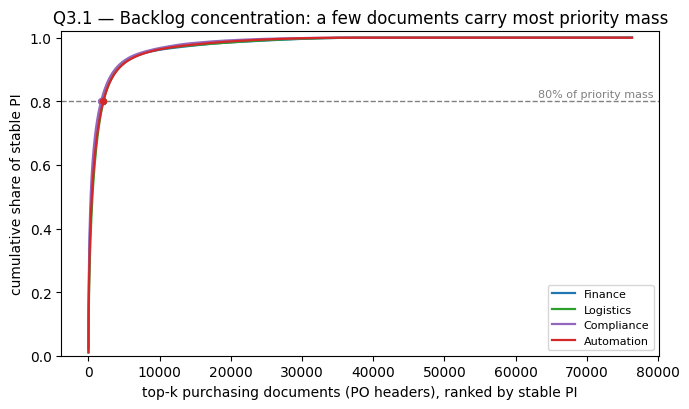

In [11]:
# =============================================================================
# 3.1 | Q3.1 — Stand-out documents: PO-header backlog and the Pareto curve
# -----------------------------------------------------------------------------
# A purchasing document becomes decision-relevant when a meaningful score gap
# and sufficient scale coincide under stable PI. The Pareto curve (paper
# Fig. 4/11) shows the cumulative stable-PI mass over top-k documents -- a
# steep early rise is the evidence that the open question "which documents
# stand out?" collapses into a BOUNDED review backlog.
# =============================================================================
doc_backlogs = {v: prio.document_backlog(df_case_scores, v) for v in views}

cum_by_view, conc_stats = {}, {}
for v in views:
    stats, cum = prio.pareto_concentration(doc_backlogs[v])
    cum_by_view[v] = cum
    conc_stats[v] = stats

print("BACKLOG CONCENTRATION — share of PO headers needed to capture priority mass")
n_docs = len(doc_backlogs[views[0]])
for v in views:
    k80, s80 = conc_stats[v][0.80]
    k95, s95 = conc_stats[v][0.95]
    print(f"  {v:<11} 80% of stable PI in top {k80:>5,} docs ({s80:.1%})   |   "
          f"95% in top {k95:>5,} docs ({s95:.1%})   of {n_docs:,}")
print("  [paper, real log: ~2–3% of PO headers capture 80%, <10% capture 95%, in all views]")

fig = viz.fig_document_pareto(cum_by_view)
plt.show()

In [12]:
# =============================================================================
# 3.2 | Q3.1 — Views are substantive: shortlist overlap (Jaccard) vs correlation
# -----------------------------------------------------------------------------
# Population-level score correlations can stay HIGH while decision-level
# shortlists DIVERGE, because shortlists are determined by the extreme tail of
# the score distribution. Changing the view changes which documents are
# reviewed first -- the views are substantive steering choices, not
# relabellings of one ranking (paper finding 6: Jaccard 0.481 Fin–Compl vs
# 0.081 Fin–Aut at score correlations 0.817 / 0.572).
# =============================================================================
jac = prio.jaccard_topk(doc_backlogs, k=CONFIG["top_k_documents"])
print(f"Top-{CONFIG['top_k_documents']} document shortlist overlap (Jaccard index) between views:")
display(jac.round(3))

corr = df_case_scores[[f"score__{v}" for v in views]].corr()
corr.index = corr.columns = views
print("\nItem-population score correlations (for contrast — note how much higher they are):")
display(corr.round(3))

Top-20 document shortlist overlap (Jaccard index) between views:


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.143,0.481,0.081
Logistics,0.143,1.000,0.212,0.250
Compliance,0.481,0.212,1.000,0.143
Automation,0.081,0.250,0.143,1.000



Item-population score correlations (for contrast — note how much higher they are):


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.782,0.817,0.570
Logistics,0.782,1.000,0.767,0.771
Compliance,0.817,0.767,1.000,0.617
Automation,0.570,0.771,0.617,1.000


TOP-10 OWNERSHIP SLICES — Automation view, ranked by stable PI (γ = 20)


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.8357,0.0087,945.7214,reservoir
1,companyID_0000,Logistics,5242,0.7880,0.0561,294.1742,mechanism
2,companyID_0000,Additives,18318,0.8346,0.0097,177.7888,mechanism
3,companyID_0000,Latex & Monomers,5007,0.8265,0.0177,88.8325,mechanism
4,companyID_0003,Real Estate,583,0.7545,0.0869,50.6384,mechanism
5,companyID_0000,NaN,3257,0.8331,0.0111,36.2934,mechanism
6,companyID_0000,Solvents,2629,0.8363,0.0080,20.9424,mechanism
7,companyID_0000,Specialty Resins,2406,0.8389,0.0054,13.1063,mechanism
8,companyID_0000,Workforce Services,127,0.7301,0.0987,12.5393,severity
9,companyID_0000,Pigments & Colorants,2593,0.8402,0.0042,10.8228,mechanism


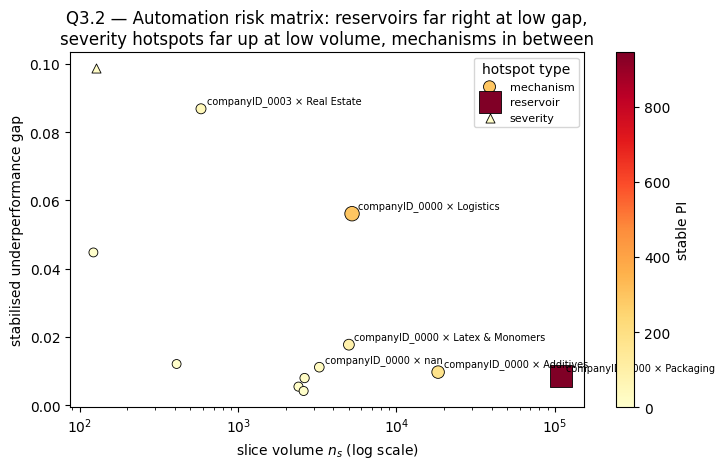

In [13]:
# =============================================================================
# 3.3 | Slice backlog, risk matrix, and focus-slice table (paper Table IX)
# -----------------------------------------------------------------------------
# Cases are mapped to the ownership slices fixed in the governance framing
# (company × spend area) and ranked by stable PI. The risk matrix (paper
# Fig. 5/12) plots volume (x, log) against stabilised gap (y): the three
# hotspot types occupy visibly different regions. We report the Automation
# view here (Q3 asks where REWORK producers concentrate); the same
# computation is available for every view.
# =============================================================================
ANALYSIS_VIEW = "Automation"
slice_keys = CONFIG["slice_keys"]
backlog = prio.slice_backlog(df_case_scores, ANALYSIS_VIEW, slice_keys,
                             exposure_col="exposure_abs_max")
typed = prio.classify_hotspots(backlog, top_n=12)

print(f"TOP-10 OWNERSHIP SLICES — {ANALYSIS_VIEW} view, ranked by stable PI "
      f"(γ = {CONFIG['shrinkage_gamma']:.0f})")
display(typed.head(10)[slice_keys + ["cases", "slice_mean", "stable_gap",
                                     "PI_stable", "hotspot_type"]].round(4))

fig = viz.fig_risk_matrix(typed, slice_keys, ANALYSIS_VIEW)
plt.show()

In [14]:
# =============================================================================
# 3.4 | Focus slices with dominant layer + leading constraint (paper Table IX)
# -----------------------------------------------------------------------------
# The bridge from the priority NUMBER to the operational MECHANISM: for each
# focus slice we name the dominant layer delta and the leading constraint
# inside it. This is the drill-down traceability promised by Phase 2 -- the
# same case-constraint penalty evidence aggregated slice-by-layer.
# =============================================================================
deltas_all = prio.slice_layer_deltas(df_case_scores, ANALYSIS_VIEW, slice_keys, norm)

# focus slices = the paper's three exemplars, taken from the typed backlog
def pick(typ):
    sub = typed[typed["hotspot_type"] == typ]
    return tuple(sub.iloc[0][slice_keys]) if len(sub) else None
focus_slices = [s for s in (pick("reservoir"), pick("mechanism"), pick("severity")) if s]

rows = []
for sl in focus_slices:
    mask = pd.Series(True, index=df_case_scores.index)
    for k_, v_ in zip(slice_keys, sl):
        mask &= df_case_scores[k_] == v_
    row_b = typed.set_index(slice_keys).loc[sl]
    dom_layer = deltas_all.loc[sl].idxmax()
    lead = prio.leading_constraint(df_case_scores, mask, dom_layer, norm)
    rows.append({
        "Slice": " × ".join(map(str, sl)),
        "Cases": int(row_b["cases"]),
        "Stable gap": float(row_b["stable_gap"]),
        "Stable PI": float(row_b["PI_stable"]),
        "Hotspot type": row_b["hotspot_type"],
        "Dominant layer delta": f"{dom_layer} ({norm['layers'][dom_layer]['name']})",
        "Leading constraint": lead.index[0],
    })
focus_table = pd.DataFrame(rows)
print("FOCUS SLICES AND THEIR DOMINANT MECHANISMS — paper Table IX, computed live")
display(focus_table.round(4))
print("\nReading across rows (paper, real log, for comparison):")
print("  reservoir : Packaging   109,199 cases at gap 0.0088 → stable PI 963.1")
print("  mechanism : Logistics     5,242 cases at gap 0.0463 → stable PI 242.4 (L4 fragmentation)")
print("  severity  : Real Estate     583 cases at gap 0.0868 → stable PI  50.6 (approval churn)")

FOCUS SLICES AND THEIR DOMINANT MECHANISMS — paper Table IX, computed live


,Slice,Cases,Stable gap,Stable PI,Hotspot type,Dominant layer delta,Leading constraint
0,companyID_0000 × Packaging,109199,0.0087,945.7214,reservoir,L3_timeliness_ageing (Handovers and ageing),c_l3_invoice_to_clear_days
1,companyID_0000 × Logistics,5242,0.0561,294.1742,mechanism,L4_rework_instability (Rework and instability),c_l4_goods_fragmentation
2,companyID_0000 × Workforce Services,127,0.0987,12.5393,severity,L2_flow_discipline (Flow-conditioned control d...,c_l2_df1_invoice_after_goods



Reading across rows (paper, real log, for comparison):
  reservoir : Packaging   109,199 cases at gap 0.0088 → stable PI 963.1
  mechanism : Logistics     5,242 cases at gap 0.0463 → stable PI 242.4 (L4 fragmentation)
  severity  : Real Estate     583 cases at gap 0.0868 → stable PI  50.6 (approval churn)


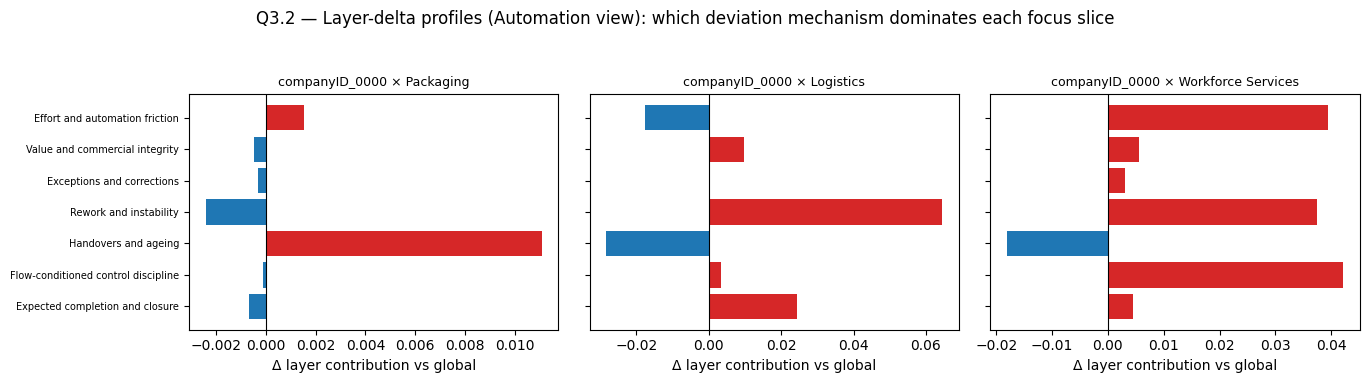

Layer-delta values (positive = more pronounced than global):


L1_closure_completeness  L2_flow_discipline  L3_timeliness_ageing  L4_rework_instability  L5_exceptions_corrections  L6_value_commercial  L7_effort_automation
case Company   case Spend area text                                                                                                                                                                
companyID_0000 Packaging                             -0.0007             -0.0001                0.0111                -0.0024                    -0.0003              -0.0005                0.0016
               Logistics                              0.0243              0.0033               -0.0283                 0.0645                     0.0005               0.0096               -0.0175
               Workforce Services                     0.0046              0.0421               -0.0180                 0.0375                     0.0031               0.0055                0.0395

In [15]:
# =============================================================================
# 3.5 | Q3.2 — Layer-delta profiles of the focus slices (paper Fig. 6/13)
# -----------------------------------------------------------------------------
# A layer delta = mean layer contribution Δ_λ^(p) in the slice MINUS the global
# mean under the same view. Positive bars mark mechanisms more pronounced in
# the slice than in the log overall. Note the paper's key observation: a
# high-priority hotspot need NOT be dominated by the view's focal layer --
# Packaging tops the Automation backlog yet its main positive delta is L3
# ageing (a backlog-resolution problem at scale), not L7 effort.
# =============================================================================
deltas_focus = deltas_all.loc[[tuple(s) for s in focus_slices]]
fig = viz.fig_layer_deltas(deltas_focus, norm, ANALYSIS_VIEW)
plt.show()

print("Layer-delta values (positive = more pronounced than global):")
display(deltas_focus.round(4))

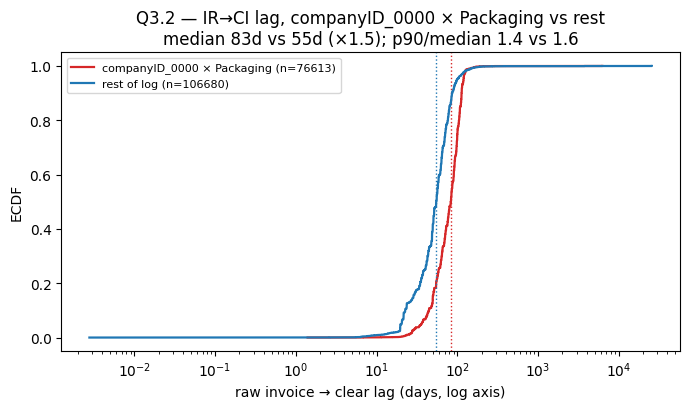

DRILL-DOWN VERDICT for companyID_0000 × Packaging:
  median in-slice 83.4d vs rest 54.7d (shift ×1.52); tail ratio p90/median 1.36 vs 1.58
  → body-wide shift → systemic queue problem (SLA/escalation/workload rebalancing)


In [16]:
# =============================================================================
# 3.6 | Q3.2 — Mechanism shape: ECDF of the raw IR→CI lag (paper Fig. 7,
#       a PLACEHOLDER in the paper — produced here with real numbers)
# -----------------------------------------------------------------------------
# The bounded L3 severities derive from an unbounded quantity: the raw
# invoice-to-clear lag in days. Its distributional SHAPE discriminates between
# intervention classes:
#   body-wide rightward shift -> systemic queue/priority problem
#                                (levers: SLA management, escalation, rebalancing)
#   heavy tail on normal body -> stuck subpopulation
#                                (lever: targeted exception triage of open items)
# The verdict below is the sentence the paper leaves as "insert the verdict
# printed by the notebook drill-down".
# =============================================================================
reservoir_slice = focus_slices[0]
mask_res = pd.Series(True, index=df_case_scores.index)
for k_, v_ in zip(slice_keys, reservoir_slice):
    mask_res &= df_case_scores[k_] == v_

t_inv = wcons.first_ts_series(df_case_scores, first_any_of=["Record Invoice Receipt", "Vendor creates invoice"])
t_clr = wcons.first_ts_series(df_case_scores, first_activity="Clear Invoice")
lag_days = (t_clr - t_inv).dt.total_seconds() / 86400.0
lag_days = lag_days.where(lag_days >= 0)

label = " × ".join(map(str, reservoir_slice))
fig, verdict = viz.fig_lag_ecdf(lag_days[mask_res], lag_days[~mask_res], label)
plt.show()
print(f"DRILL-DOWN VERDICT for {label}:")
print(f"  median in-slice {verdict['median_in']:.1f}d vs rest {verdict['median_out']:.1f}d "
      f"(shift ×{verdict['shift_ratio']:.2f}); tail ratio p90/median "
      f"{verdict['tail_in']:.2f} vs {verdict['tail_out']:.2f}")
print(f"  → {verdict['verdict']}")

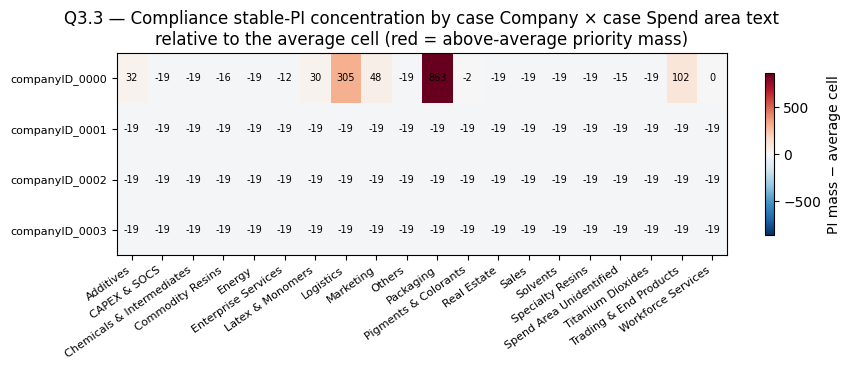

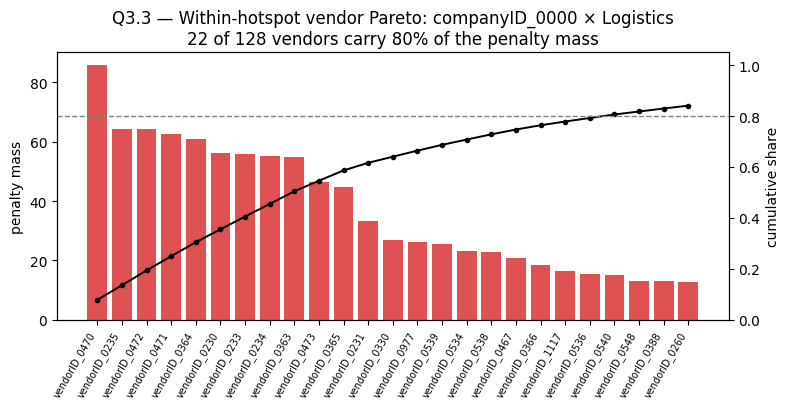

WITHIN-HOTSPOT CONCENTRATION: 22 of 128 vendors inside companyID_0000 × Logistics carry 80% of its Automation penalty mass.
Leading counterparties: vendorID_0470, vendorID_0235, vendorID_0472, vendorID_0471, vendorID_0364


In [17]:
# =============================================================================
# 3.7 | Q3.3 — Ownership heatmap (paper Fig. 8/14) and within-hotspot vendor
#       Pareto (paper Fig. 9, a PLACEHOLDER in the paper — produced here)
# -----------------------------------------------------------------------------
# The heatmap LOCALISES priority mass to nameable owners; the mechanism behind
# each cell came from the risk matrix and layer-delta drill-down above. The
# literal Q3 wording -- "which customers produce a lot of rework" -- is
# answered one level deeper, INSIDE a hotspot: the slice names the owner, the
# vendor Pareto names the counterparties to start supplier-management,
# contracting, and master-data conversations with.
# =============================================================================
heat_backlog = prio.slice_backlog(df_case_scores, "Compliance", slice_keys)
fig = viz.fig_ownership_heatmap(heat_backlog, slice_keys, "Compliance")
plt.show()

# vendor Pareto inside the mechanism hotspot (penalty mass = Σ (1 − S) per vendor)
mech_slice = focus_slices[1] if len(focus_slices) > 1 else focus_slices[0]
mask_mech = pd.Series(True, index=df_case_scores.index)
for k_, v_ in zip(slice_keys, mech_slice):
    mask_mech &= df_case_scores[k_] == v_
sub = df_case_scores.loc[mask_mech].dropna(subset=[f"score__{ANALYSIS_VIEW}"])
vendor_penalty = (1 - sub[f"score__{ANALYSIS_VIEW}"]).groupby(sub["case Vendor"]).sum()

mech_label = " × ".join(map(str, mech_slice))
fig, kk = viz.fig_vendor_pareto(vendor_penalty, mech_label)
plt.show()
print(f"WITHIN-HOTSPOT CONCENTRATION: {kk['k']} of {kk['K']} vendors inside {mech_label} carry "
      f"{kk['threshold']:.0%} of its {ANALYSIS_VIEW} penalty mass.")
print("Leading counterparties:", ", ".join(vendor_penalty.sort_values(ascending=False).head(5).index))

**Output of Phase 3** *(Figure 2 purple band)* — a **ranked document/slice backlog + hotspot
explanation**: a bounded document shortlist (Q3.1), a typed slice backlog whose top entries are
explained by dominant layers and leading constraints (Q3.2), and ownership/counterparty
localisation (Q3.3). Everything remains *descriptive*: the artefacts motivate **which follow-up
analysis to run**, not which intervention will succeed.

---
## 4 · Governance loop — review evidence → validate assumptions → refine → rerun
*(Figure 2, grey band.)*

The loop is **contextual rather than formal** — not a separate algorithm, but the iterative
character of BPM practice made operational. Before any steering conclusion, WISE asks of every
finding: **is this a process issue or a measurement issue?** Three diagnostics, all computed from
the already-scored data:

1. **Right-censoring flag** — an invoice-bearing item without *Clear Invoice* that is still active
   within the final **60 days** of the observation window may simply lack time to finish. Counting
   it as backlog confuses window truncation with process failure.
2. **Event-replication ratio** — events per *distinct timestamp*, per item; a ratio **> 2** signals
   extraction-level duplication (BPIC'19 is known to replicate SES-related events). The "rework"
   may be a logging artefact — verify source-system semantics before process conclusions.
3. **Censoring-robust gap retention** — recompute each focus slice's stable gap on **non-censored
   items only** and report the retained share. If a slice's priority collapses, its hotspot status
   is a window artefact — and **demoting it is the intended behaviour of the loop, not a failure of
   the method.**

### Paper Table X — here with *real* numbers

The paper presents Table X with `xx%` placeholders ("values are produced by the accompanying
notebook"). The next cell **is** that notebook computation: per focus slice it reports the
right-censored share, the replicated-event share, the gap retained excluding censored items, and an
auto-generated *reading* that mirrors the paper's example readings
(*"gap largely retained → the ageing reservoir is not a window artefact"*,
*"elevated replication → verify SES logging semantics"*, *"robust → local review can proceed"*).

In [18]:
# =============================================================================
# 4.1 | TABLE X — governance-loop validation with real numbers
# -----------------------------------------------------------------------------
# Definitions (paper Table X notes):
#   Right-censored   = invoice-bearing item without Clear Invoice still active
#                      within 60 days of the window end.
#   Replicated event = item-level event-replication ratio above 2
#                      (events per distinct timestamp).
#   Gap retained     = stable gap recomputed on non-censored items as a share
#                      of the original stable gap.
# =============================================================================
d_gov = gov.add_governance_flags(df_case_scores)
window_end = d_gov["_window_end"].iloc[0]
print(f"Observation window ends {window_end.date()} | censoring horizon = last "
      f"{CONFIG['censoring_window_days']} days | replication flag > {CONFIG['replication_ratio_flag']}")
print(f"Global: {d_gov['is_right_censored'].mean():.1%} of all items right-censored | "
      f"{d_gov['is_replicated'].mean():.1%} replication-flagged")

cens_among_open = float(d_gov.loc[d_gov["is_open_invoice"], "is_right_censored"].mean())
print(f"Of the items violating the closure constraint, {cens_among_open:.1%} are right-censored "
      f"→ that share of the open-item rate reflects incomplete observation, not process backlog.")

table_x = gov.governance_table(d_gov, ANALYSIS_VIEW, focus_slices)
print("\nTABLE X — GOVERNANCE-LOOP VALIDATION: DATA-QUALITY QUALIFICATION OF THE FOCUS SLICES")
display(table_x.style.format({
    "right_censored_share": "{:.1%}", "replicated_event_share": "{:.1%}",
    "stable_gap_all": "{:.4f}", "stable_gap_excl_censored": "{:.4f}",
    "gap_retained_excl_censored": "{:.1%}"}) if hasattr(table_x, "style") else table_x)

print("\nHOW TO READ EACH ROW (mirrors the paper's example readings):")
for _, r in table_x.iterrows():
    print(f"\n  {r['focus_slice']}  ({r['cases']:,} cases)")
    print(f"    right-censored {r['right_censored_share']:.1%} | replicated {r['replicated_event_share']:.1%} "
          f"| gap retained excl. censored {r['gap_retained_excl_censored']:.1%}")
    print(f"    → {r['reading']}")

Observation window ends 2020-04-09 | censoring horizon = last 60 days | replication flag > 2.0
Global: 0.0% of all items right-censored | 1.7% replication-flagged
Of the items violating the closure constraint, 0.0% are right-censored → that share of the open-item rate reflects incomplete observation, not process backlog.

TABLE X — GOVERNANCE-LOOP VALIDATION: DATA-QUALITY QUALIFICATION OF THE FOCUS SLICES


,focus_slice,cases,right_censored_share,replicated_event_share,stable_gap_all,stable_gap_excl_censored,gap_retained_excl_censored,reading
0,companyID_0000 × Packaging,109199,0.0%,0.0%,0.0087,0.0087,100.0%,gap largely retained → hotspot is not a window artefact; robust → local review can proceed
1,companyID_0000 × Logistics,5242,0.0%,72.5%,0.0561,0.0561,100.0%,gap largely retained → hotspot is not a window artefact; elevated replication → verify SES/GR logging semantics before process conclusions
2,companyID_0000 × Workforce Services,127,0.0%,34.6%,0.0987,0.0987,100.0%,gap largely retained → hotspot is not a window artefact; elevated replication → verify SES/GR logging semantics before process conclusions



HOW TO READ EACH ROW (mirrors the paper's example readings):

  companyID_0000 × Packaging  (109,199 cases)
    right-censored 0.0% | replicated 0.0% | gap retained excl. censored 100.0%
    → gap largely retained → hotspot is not a window artefact; robust → local review can proceed

  companyID_0000 × Logistics  (5,242 cases)
    right-censored 0.0% | replicated 72.5% | gap retained excl. censored 100.0%
    → gap largely retained → hotspot is not a window artefact; elevated replication → verify SES/GR logging semantics before process conclusions

  companyID_0000 × Workforce Services  (127 cases)
    right-censored 0.0% | replicated 34.6% | gap retained excl. censored 100.0%
    → gap largely retained → hotspot is not a window artefact; elevated replication → verify SES/GR logging semantics before process conclusions


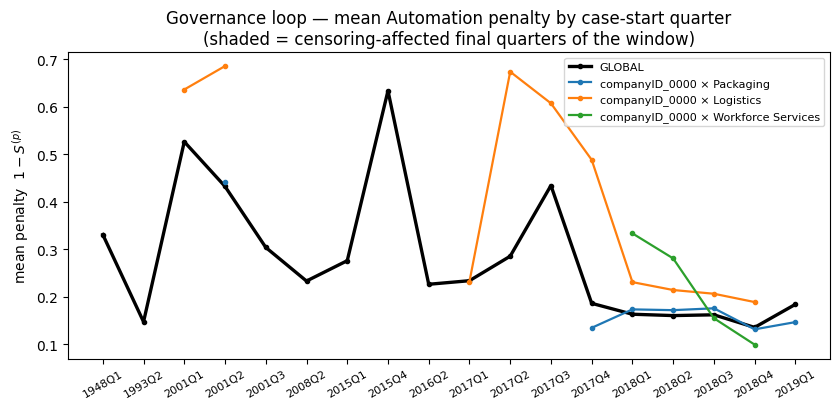

Cohort coverage of the focus mechanisms (share of quarters with data):
  companyID_0000 × Packaging                    visible in 39% of case-start cohorts → check for drift / cohort concentration
  companyID_0000 × Logistics                    visible in 56% of case-start cohorts → check for drift / cohort concentration
  companyID_0000 × Workforce Services           visible in 22% of case-start cohorts → check for drift / cohort concentration


In [19]:
# =============================================================================
# 4.2 | Quarterly trend (paper Fig. 10, a PLACEHOLDER in the paper)
# -----------------------------------------------------------------------------
# Mean penalty (1 − S) by case-start quarter for the focus slices vs the global
# baseline; the shaded zone marks the censoring-affected final quarters.
# This separates CHRONIC problems (visible across cohorts) from DRIFT
# (concentrated in specific quarters) and from window-truncation artefacts.
# =============================================================================
trend = gov.quarterly_penalty_trend(d_gov, ANALYSIS_VIEW, focus_slices)
quarters = list(trend.index)
horizon = window_end - pd.Timedelta(days=CONFIG["censoring_window_days"])
censor_quarters = [q for q in quarters if pd.Period(q).end_time >= horizon]
fig = viz.fig_quarterly_trend(trend, censor_quarters, ANALYSIS_VIEW)
plt.show()

chronic = (trend.drop(columns=["GLOBAL"]).notna().mean() > 0.7)
print("Cohort coverage of the focus mechanisms (share of quarters with data):")
for c in trend.columns:
    if c == "GLOBAL":
        continue
    cov = trend[c].notna().mean()
    print(f"  {c:<45} visible in {cov:.0%} of case-start cohorts → "
          f"{'chronic pattern' if cov > 0.7 else 'check for drift / cohort concentration'}")

In [20]:
# =============================================================================
# 4.3 | Evaluation summary — paper Table XI, computed live
# -----------------------------------------------------------------------------
# One row per principal finding: the claim, its key evidence (from THIS run),
# and the implication for Q3 steering. This is the full arc of Fig. 2: the
# flow-aware norm defines WHAT counts as a problem; view-weighted scoring
# defines FOR WHOM it matters; PI aggregation defines WHERE it matters at
# scale; the drill-downs explain WHICH mechanism dominates; and the
# governance loop states HOW MUCH each finding can be trusted.
# =============================================================================
k80, s80 = conc_stats[ANALYSIS_VIEW][0.80]
k95, s95 = conc_stats[ANALYSIS_VIEW][0.95]
fs = focus_table
gx = table_x
summary = pd.DataFrame([
    {"#": 1, "Finding": "Deviation priority is strongly concentrated",
     "Key evidence (this run)": f"{s80:.1%} of PO headers capture 80% of stable PI; {s95:.1%} capture 95% ({ANALYSIS_VIEW})",
     "Implication for Q3": "Q3.1: stand-outs form a bounded, assignable review backlog"},
    {"#": 2, "Finding": "Dominant global mechanisms are closure and ageing",
     "Key evidence (this run)": f"{open_rate:.1%} of invoice-bearing items miss Clear Invoice; {ageing_pos:.1%} show positive IR→CI ageing",
     "Implication for Q3": "Q3.2: much of the log behaves like slowly resolved work-in-progress"},
    {"#": 3, "Finding": "High priority arises for three different reasons",
     "Key evidence (this run)": "; ".join(f"{r['Hotspot type']}: {r['Slice'].split(' × ')[1]} "
                                          f"({r['Cases']:,} cases, gap {r['Stable gap']:.4f})"
                                          for _, r in fs.iterrows()),
     "Implication for Q3": "Each hotspot type implies a different follow-up: queue mgmt at scale / targeted redesign / local review"},
    {"#": 4, "Finding": "Mechanism shape discriminates the intervention",
     "Key evidence (this run)": f"IR→CI ECDF: median ×{verdict['shift_ratio']:.1f} shift, tails {verdict['tail_in']:.1f} vs {verdict['tail_out']:.1f}",
     "Implication for Q3": verdict["verdict"]},
    {"#": 5, "Finding": "Priority mass localises to nameable owners & counterparties",
     "Key evidence (this run)": f"{kk['k']} of {kk['K']} vendors carry 80% of the {mech_label} penalty",
     "Implication for Q3": "Q3.3: rework producers are concrete segments and vendors"},
    {"#": 6, "Finding": "Stakeholder views change the practical shortlist",
     "Key evidence (this run)": f"top-20 Jaccard ranges {jac.values[~np.eye(len(jac), dtype=bool)].min():.3f}–"
                                f"{jac.values[~np.eye(len(jac), dtype=bool)].max():.3f} across view pairs",
     "Implication for Q3": "Views are substantive steering choices on the same evidence"},
    {"#": 7, "Finding": "Findings are robust to, or qualified by, data-semantics risks",
     "Key evidence (this run)": "gap retained " + " / ".join(f"{g:.0%}" for g in gx["gap_retained_excl_censored"]) +
                                f"; {cens_among_open:.0%} of closure violations censored",
     "Implication for Q3": "Each steering claim carries an explicit degree of trust"},
])
print("SUMMARY OF THE EVALUATION — principal findings (paper Table XI, live numbers)")
display(summary.set_index("#"))

SUMMARY OF THE EVALUATION — principal findings (paper Table XI, live numbers)


,Finding,Key evidence (this run),Implication for Q3
#,,,
1,Deviation priority is strongly concentrated,2.7% of PO headers capture 80% of stable PI; 1...,"Q3.1: stand-outs form a bounded, assignable re..."
2,Dominant global mechanisms are closure and ageing,13.3% of invoice-bearing items miss Clear Invo...,Q3.2: much of the log behaves like slowly reso...
3,High priority arises for three different reasons,"reservoir: Packaging (109,199 cases, gap 0.008...",Each hotspot type implies a different follow-u...
4,Mechanism shape discriminates the intervention,"IR→CI ECDF: median ×1.5 shift, tails 1.4 vs 1.6",body-wide shift → systemic queue problem (SLA/...
5,Priority mass localises to nameable owners & c...,22 of 128 vendors carry 80% of the companyID_0...,Q3.3: rework producers are concrete segments a...
6,Stakeholder views change the practical shortlist,top-20 Jaccard ranges 0.081–0.481 across view ...,Views are substantive steering choices on the ...
7,"Findings are robust to, or qualified by, data-...",gap retained 100% / 100% / 100%; 0% of closure...,Each steering claim carries an explicit degree...


---
## 5 · Reading the results, the loop's next iteration, and limitations

**Reading the backlog.** The output is stratified, mirroring the questions: *global findings*
(closure + ageing dominate the log) set the theme; the *document Pareto* turns "which documents
stand out?" into a bounded review list; the *typed slice backlog* says **where** to act and —
through the typology — **what kind** of action fits; the *layer/constraint drill-downs* say
**which mechanism** to investigate; and **Table X** says **how much to trust** each claim before
steering.

**What the governance loop does next** (review → validate → **refine** → rerun): findings flagged
in Table X feed back into Phase 1 — e.g. verify SES logging semantics where replication is
elevated, then either correct the extraction or add an applicability rule excluding duplicated
service postings; revisit lag thresholds $\delta, \Delta$ with the owning roles; re-version the
norm (`bpic19_norm_v2.json`) and rerun. Priorities can then be **monitored and compared across
time and stakeholders** because every artefact — norm, weights, aggregation — is explicit and
versioned.

**Limitations** (inherited from the paper, and honest ones):

* **Descriptive, not causal.** WISE motivates which follow-up analysis to run, not which
  intervention will succeed.
* **The norm is a benchmark instantiation.** Without access to the BPIC'19 process owners, the
  29 constraints encode domain knowledge + challenge documentation; the layer weights in
  Table VIII are illustrative settings, not elicited priorities.
* **Value coverage is proxy-based.** Value-related issues enter through commercially relevant
  change signals and exposure-aware slicing, not a full object-level invoice–receipt matching
  audit; results locate where commercially relevant change behaviour concentrates, not financial
  correctness.
* **Synthetic fallback ≠ real log.** When run without the real CSV, the numbers validate the
  *pipeline* (planted patterns are rediscovered and correctly typed/qualified); the paper's
  reference numbers for the real log are quoted inline at every step for comparison.

**Reproducibility.** Norm: `norm/bpic19_norm_v1.json` · package: `wise_eval/` · figures:
`figures/generated/` · seed fixed in `wise_eval/config.py`. Place `BPI_Challenge_2019.csv` in `data/`
and re-run Run-All to reproduce the evaluation on the real log.